# Converting rotations
Convert rotations from blender to SpinDOE and Martius

In [33]:
import numpy as np
import torch
import roma

In [3]:
rot_vecA = np.array([2.0, 0.0, 0.0])
rot_vecB = np.array([0.0, 2.0, 0.0])
rot_vecC = np.array([10.0, 2.0, -5.0])

# Transform exponential to Rotation matrix

In [24]:
def euler_angle_to_matrix(euler_angle: np.array) -> np.ndarray:
    """Convert euler angles to rotation matrix.
    using the Rodriguez rotation formula

    Args:
        euler_angle (np.ndarray): Euler angles in radians.

    Returns:
        np.ndarray: Rotation matrix.
    """
    theta = np.linalg.norm(euler_angle)
    euler_angle = euler_angle / theta
    K = np.array([[0, -euler_angle[2], euler_angle[1]],[euler_angle[2], 0, -euler_angle[0]],[ -euler_angle[1], euler_angle[0], 0]])
    matrix = np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * np.matmul(K, K)
    return matrix

In [25]:
rot_matA = euler_angle_to_matrix(rot_vecA)
print(f"Rotation Matrix A:\n{rot_matA}\n")

Rotation Matrix A:
[[ 1.          0.          0.        ]
 [ 0.         -0.41614684 -0.90929743]
 [ 0.          0.90929743 -0.41614684]]



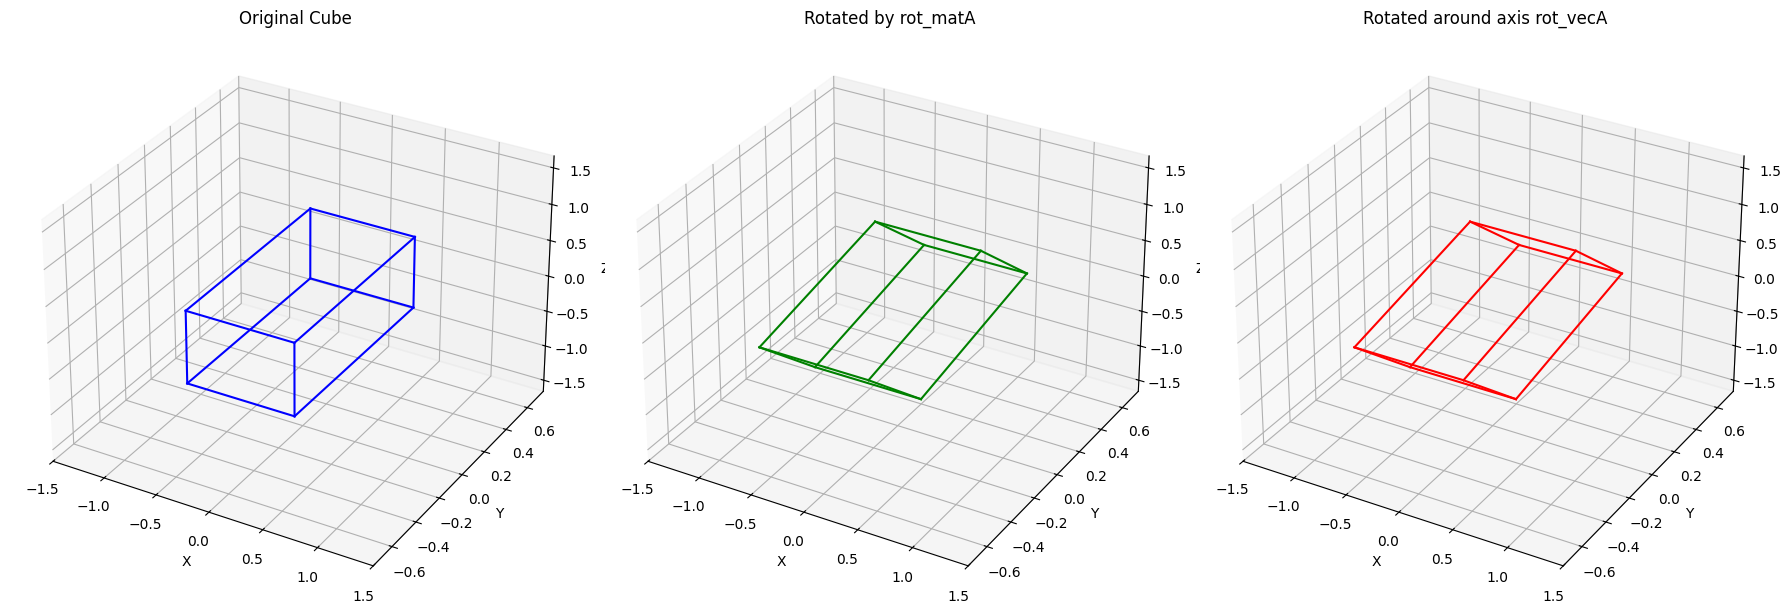

In [27]:
from mpl_toolkits.mplot3d import Axes3D

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(18, 6))

# 1. Original Cube
ax1 = fig.add_subplot(131, projection='3d')
ax1.set_title('Original Cube')
for edge in edges:
    ax1.plot(*cube_vertices[edge].T, color='b')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.set_xlim(xlim)
ax1.set_ylim(ylim)
ax1.set_zlim(zlim)

# 2. Cube rotated by rot_matA
rotated_by_matA = cube_vertices @ rot_matA.T
ax2 = fig.add_subplot(132, projection='3d')
ax2.set_title('Rotated by rot_matA')
for edge in edges:
    ax2.plot(*rotated_by_matA[edge].T, color='g')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.set_xlim(xlim)
ax2.set_ylim(ylim)
ax2.set_zlim(zlim)

# 3. Cube rotated around axis rot_vecA
def axis_angle_to_matrix(axis: np.ndarray, angle: float) -> np.ndarray:
    axis = axis / np.linalg.norm(axis)
    K = np.array([[0, -axis[2], axis[1]],
                  [axis[2], 0, -axis[0]],
                  [-axis[1], axis[0], 0]])
    I = np.eye(3)
    return I + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)

angleA = np.linalg.norm(rot_vecA)
axisA = rot_vecA / angleA
rot_mat_axisA = axis_angle_to_matrix(axisA, angleA)
rotated_by_axisA = cube_vertices @ rot_mat_axisA.T

ax3 = fig.add_subplot(133, projection='3d')
ax3.set_title('Rotated around axis rot_vecA')
for edge in edges:
    ax3.plot(*rotated_by_axisA[edge].T, color='r')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.set_xlim(xlim)
ax3.set_ylim(ylim)
ax3.set_zlim(zlim)

plt.tight_layout()
plt.show()

# Rotation matrix to euler angles

In [31]:
def matrix_to_axis_angle(R: np.ndarray):
    """
    Convert a rotation matrix to axis-angle representation.

    Args:
        R (np.ndarray): 3x3 rotation matrix.

    Returns:
        axis (np.ndarray): Rotation axis (unit vector).
        angle (float): Rotation angle in radians.
    """
    angle = np.arccos((np.trace(R) - 1) / 2)
    if np.isclose(angle, 0):
        axis = np.array([1, 0, 0])
    else:
        axis = np.array([
            R[2, 1] - R[1, 2],
            R[0, 2] - R[2, 0],
            R[1, 0] - R[0, 1]
        ]) / (2 * np.sin(angle))
    return axis, angle

def matrix_to_euler(R: np.ndarray):
    """
    Convert a rotation matrix to Euler angles (roll, pitch, yaw).

    Args:
        R (np.ndarray): 3x3 rotation matrix.

    Returns:
        euler_angles (np.ndarray): Euler angles in radians.
    """
    axis, angle = matrix_to_axis_angle(R)
    return axis * angle

# Example usage:
axis, angle = matrix_to_axis_angle(rot_matA)
print("Axis:", axis)
print("Angle:", angle)
print("Euler", matrix_to_euler(rot_matA))
print("rot_vecA:", rot_vecA)

Axis: [1. 0. 0.]
Angle: 2.0
Euler [2. 0. 0.]
rot_vecA: [2. 0. 0.]


# Use SVD to recover R from matrix

In [38]:
def procrustes_to_rotmat(A: np.ndarray) -> np.ndarray:
    """
    Use SVD to recover the closest rotation matrix from a given matrix A.

    Args:
        A (np.ndarray): Input matrix.
    """
    # perform SVD+
    u, s, v = np.linalg.svd(A)
    det = np.linalg.det(u @ v.T)
    dia = np.diag([1, 1, det])
    R = u @ dia @ v.T
    # roma needs torch tensors [B, 3, 3]
    # print(R.shape)
    R_torch = torch.tensor(R, dtype=torch.float32).unsqueeze(0)
    R_roma = roma.special_procrustes(R_torch).squeeze(0).numpy()
    return R_roma

In [39]:
mat = procrustes_to_rotmat(rot_matA + 0.1 * np.random.randn(3,3))
print(f"Recovered Rotation Matrix:\n{mat}\n")
print("Recovered Euler:", matrix_to_euler(mat))
print("Original Euler:", rot_vecA)

Recovered Rotation Matrix:
[[ 0.9729748   0.10197523 -0.20717391]
 [-0.17929484 -0.23174223 -0.95611125]
 [-0.14551061  0.9674175  -0.2071958 ]]

Recovered Euler: [ 1.7860374  -0.05725569 -0.2611653 ]
Original Euler: [2. 0. 0.]
